In [ ]:
# !cp -r /content/drive/MyDrive/Colab/Advanced_AI/data /content/

'cp' is not recognized as an internal or external command,
operable program or batch file.


In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
from tensorflow.python.client import device_lib
devices = device_lib.list_local_devices()
for device in devices:
    if device.device_type == 'GPU':
        print(device.name, device.physical_device_desc)

In [3]:
def build_binary_resnet50(input_shape=(224, 224, 3), num_classes=1):
    """
    Xây dựng mô hình CNN dựa trên ResNet50 đã được huấn luyện trước (pre-trained)
    sử dụng transfer learning.

    Args:
        input_shape (tuple): Kích thước của ảnh đầu vào (height, width, channels).
                             Mặc định là (224, 224, 3) cho ResNet50.
        num_classes (int): Số lượng lớp đầu ra.
                           - 1 cho phân loại nhị phân (với activation 'sigmoid').
                           - >1 cho phân loại đa lớp (với activation 'softmax').

    Returns:
        tensorflow.keras.models.Sequential: Mô hình Keras đã được xây dựng.
    """
    base_model = ResNet50(weights='imagenet',
                             include_top=False,
                             input_shape=input_shape)
    # 2. Đóng băng các trọng số của base_model để không cập nhật trong quá trình huấn luyện ban đầu
    #    Chúng ta chỉ muốn huấn luyện các lớp mới thêm vào.
    base_model.trainable = False

    # 3. Xây dựng mô hình Sequential mới
    model = models.Sequential(name='Custom_ResNet50')

    # 4. Thêm base_model (đã đóng băng) vào mô hình mới
    model.add(base_model)

    # 5. Thêm lớp GlobalAveragePooling2D để giảm chiều dữ liệu từ output của base_model
    #    thành một vector đặc trưng duy nhất cho mỗi ảnh.
    model.add(layers.GlobalAveragePooling2D(name='global_avg_pool'))

    # 6. Thêm lớp Dropout để giảm overfitting (tùy chọn nhưng thường hữu ích)
    model.add(layers.Dropout(0.5, name='dropout_top'))

    # 7. Thêm lớp Dense cuối cùng để phân loại
    if num_classes == 1:
        # Phân loại nhị phân
        activation = 'sigmoid'
        output_layer_name = 'predictions_binary'
    else:
        # Phân loại đa lớp
        activation = 'softmax'
        output_layer_name = 'predictions_multiclass'

    model.add(layers.Dense(num_classes, activation=activation, name=output_layer_name))

    return model

In [4]:
def build_binary_resnet50_v2(input_shape=(224, 224, 3), num_classes=1):
    base_model = ResNet50(weights='imagenet',
                             include_top=False,
                             input_shape=input_shape)
    base_model.trainable = False

    model = models.Sequential(name='Custom_ResNet50')

    model.add(base_model)
    model.add(layers.GlobalAveragePooling2D(name='global_avg_pool'))
    model.add(layers.Dropout(0.5, name='dropout_top'))

    # !!! Bước thử nghiệm hoặc 256, 512 (Thêm Dense trung gian trước khi ra output)
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3, name='dropout_fc1'))  # tùy chọn

    model.add(layers.Dense(num_classes, activation='sigmoid', name='predictions_binary'))

    return model

In [5]:
INPUT_SHAPE = (224, 224, 3)

custom_model_resnet_v1 = build_binary_resnet50(input_shape=INPUT_SHAPE, num_classes=1)

In [6]:
custom_model_resnet_v1.summary()

Model: "Custom_ResNet50"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_avg_pool (GlobalAver  (None, 2048)             0         
 agePooling2D)                                                   
                                                                 
 dropout_top (Dropout)       (None, 2048)              0         
                                                                 
 predictions_binary (Dense)  (None, 1)                 2049      
                                                                 
Total params: 23,589,761
Trainable params: 2,049
Non-trainable params: 23,587,712
_________________________________________________________________


### Train model

In [7]:
learning_rate = 1e-4
EPOCHS = 10
BATCH_SIZE = 32

In [8]:
base_dir = "../data"

train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "validation")

train_cats_dir = os.path.join(train_dir, "cats")
train_dogs_dir = os.path.join(train_dir, "dogs")

validation_cats_dir = os.path.join(validation_dir, "cats")
validation_dogs_dir = os.path.join(validation_dir, "dogs")

In [9]:
train_cat_frame = os.listdir(train_cats_dir)
train_dog_frame = os.listdir(train_dogs_dir)

validation_cat_frame = os.listdir(validation_cats_dir)
validation_dog_frame = os.listdir(validation_dogs_dir)

print(f"Total training cat images: {len(train_cat_frame)}")
print(f"Total training dog images: {len(train_dog_frame)}")
print(f"Total validation cat images: {len(validation_cat_frame)}")
print(f"Total validation dog images: {len(validation_dog_frame)}")

Total training cat images: 1000
Total training dog images: 1000
Total validation cat images: 504
Total validation dog images: 504


In [10]:
training_data_dir = train_dir
validation_data_dir = validation_dir
test_data_dir = validation_dir

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)

In [12]:
train_generator = train_datagen.flow_from_directory(
    training_data_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1008 images belonging to 2 classes.


In [13]:
custom_model_resnet_v1.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=learning_rate), # Hoặc RMSprop(learning_rate=learning_rate)
    metrics=['accuracy']
)

In [14]:
checkpoint_filepath = '/content/drive/MyDrive/Colab/Advanced_AI/data/custom_retnet50_v1_best.keras'

model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False, # Lưu toàn bộ model bao gồm cả weights và cấu trúc
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

In [15]:
# Dừng sớm
early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Theo dõi validation loss
    patience=5,         # Số epoch chờ đợi trước khi dừng nếu không cải thiện
    verbose=1,
    restore_best_weights=True # Khôi phục trọng số tốt nhất khi dừng
)

In [16]:
# Giảm learning rate
reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2, # learning_rate = learning_rate * factor
    patience=3,
    min_lr=1e-7, # Giới hạn dưới của learning rate
    verbose=1
)

In [17]:
# len(train_generator) <=> num_samples // batch_size
# len(validation_generator) <=> num_samples // batch_size
history = custom_model_resnet_v1.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=[model_checkpoint_callback, early_stopping_callback, reduce_lr_callback],
)

Epoch 1/10
63/63 [==============================] - 65s 871ms/step - loss: 0.7736 - accuracy: 0.5110 - val_loss: 0.6971 - val_accuracy: 0.4643 - lr: 1.0000e-04
Epoch 2/10
63/63 [==============================] - 45s 723ms/step - loss: 0.7438 - accuracy: 0.5310 - val_loss: 0.6951 - val_accuracy: 0.5179 - lr: 1.0000e-04
Epoch 3/10
63/63 [==============================] - 46s 722ms/step - loss: 0.7596 - accuracy: 0.5065 - val_loss: 0.6924 - val_accuracy: 0.5446 - lr: 1.0000e-04
Epoch 4/10
63/63 [==============================] - 47s 744ms/step - loss: 0.7544 - accuracy: 0.4870 - val_loss: 0.6898 - val_accuracy: 0.5546 - lr: 1.0000e-04
Epoch 5/10
63/63 [==============================] - 83s 1s/step - loss: 0.7358 - accuracy: 0.5145 - val_loss: 0.6867 - val_accuracy: 0.5337 - lr: 1.0000e-04
Epoch 6/10
63/63 [==============================] - 87s 1s/step - loss: 0.7382 - accuracy: 0.5100 - val_loss: 0.6849 - val_accuracy: 0.5288 - lr: 1.0000e-04
Epoch 7/10
63/63 [============================

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

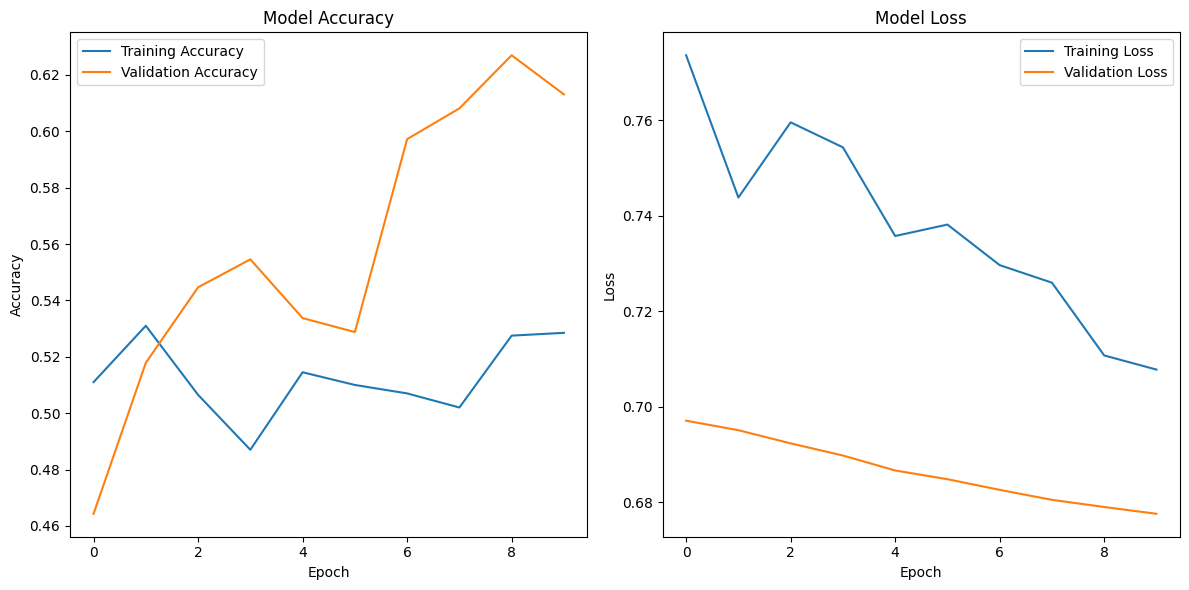

In [23]:
# Vẽ Accuracy
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Vẽ Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Thử nghiệm với layer khác của Resnet

In [32]:
custom_model_resnet_v2 = build_binary_resnet50_v2(input_shape=INPUT_SHAPE, num_classes=1)

In [33]:
custom_model_resnet_v2.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=learning_rate), # Hoặc RMSprop(learning_rate=learning_rate)
    metrics=['accuracy']
)

In [34]:
custom_model_resnet_v2.summary()

Model: "Custom_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_avg_pool                      │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_top (Dropout)                │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_fc1 (Dropout)                │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions_binary (Dense)           │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [52]:
# Lấy base_model ra
base_model = custom_model_resnet_v2.layers[0]
base_model.trainable = True

# Chỉ mở khóa một phần, ví dụ 100 layer cuối
for layer in base_model.layers[:-100]:
    layer.trainable = False

In [53]:
custom_model_resnet_v2.compile(optimizer=optimizers.Adam(1e-5),  # rất quan trọng: giảm LR
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [54]:
# len(train_generator) <=> num_samples // batch_size
# len(validation_generator) <=> num_samples // batch_size
history2 = custom_model_resnet_v2.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=[model_checkpoint_callback, early_stopping_callback, reduce_lr_callback],
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 142s 914ms/step - accuracy: 0.5456 - loss: 0.7653 - val_accuracy: 0.5000 - val_loss: 0.8824 - learning_rate: 1.0000e-05
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 544ms/step - accuracy: 0.5639 - loss: 0.7418 - val_accuracy: 0.5069 - val_loss: 0.7547 - learning_rate: 1.0000e-05
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 627ms/step - accuracy: 0.5837 - loss: 0.7138 - val_accuracy: 0.5159 - val_loss: 0.7605 - learning_rate: 1.0000e-05
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 651ms/step - accuracy: 0.5943 - loss: 0.6885 - val_accuracy: 0.5417 - val_loss: 0.7000 - learning_rate: 1.0000e-05
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 75s 545ms/step - accuracy: 0.5914 - loss: 0.6789 - val_accuracy: 0.5982 - val_loss: 0.6681 - learning_rate: 1.0000e-05
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 611ms/step - accuracy: 0.5936 - loss: 0.6826 - val_accuracy: 0.6429 - val_loss: 0.6172 - learning_rate: 1.0000e-05
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 621ms/step - ac

In [55]:
custom_model_resnet_v2.compile(optimizer=optimizers.Adam(1e-5),  # rất quan trọng: giảm LR
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [56]:
# len(train_generator) <=> num_samples // batch_size
# len(validation_generator) <=> num_samples // batch_size
history2 = custom_model_resnet_v2.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=[model_checkpoint_callback, early_stopping_callback, reduce_lr_callback],
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 88s 798ms/step - accuracy: 0.6763 - loss: 0.5958 - val_accuracy: 0.7411 - val_loss: 0.5156 - learning_rate: 1.0000e-05
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 58s 630ms/step - accuracy: 0.6806 - loss: 0.6060 - val_accuracy: 0.7421 - val_loss: 0.5294 - learning_rate: 1.0000e-05
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 626ms/step - accuracy: 0.6789 - loss: 0.5906 - val_accuracy: 0.7530 - val_loss: 0.5070 - learning_rate: 1.0000e-05
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 600ms/step - accuracy: 0.6723 - loss: 0.6025 - val_accuracy: 0.7450 - val_loss: 0.5154 - learning_rate: 1.0000e-05
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 582ms/step - accuracy: 0.6959 - loss: 0.5764 - val_accuracy: 0.7619 - val_loss: 0.4960 - learning_rate: 1.0000e-05
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 590ms/step - accuracy: 0.6865 - loss: 0.5794 - val_accuracy: 0.7520 - val_loss: 0.5157 - learning_rate: 1.0000e-05
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 546ms/step - acc

### Accuracy, Loss

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

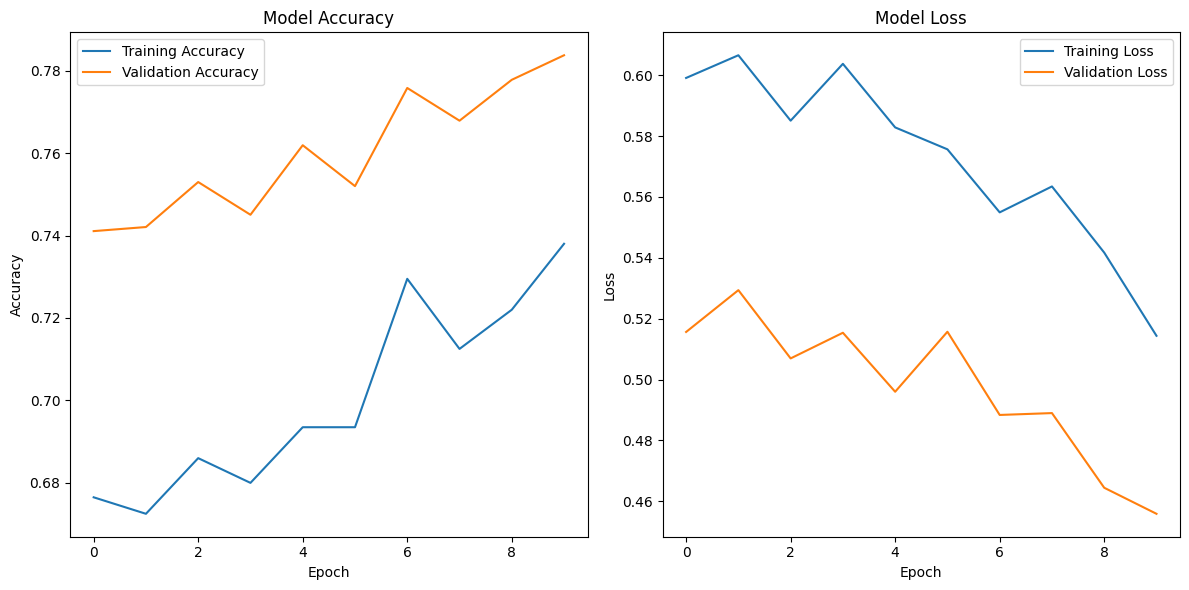

In [58]:
# Vẽ Accuracy
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Vẽ Loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
history2 = custom_model_resnet_v2.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=30,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=[model_checkpoint_callback, early_stopping_callback, reduce_lr_callback],
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 613ms/step - accuracy: 0.7589 - loss: 0.4970 - val_accuracy: 0.7847 - val_loss: 0.4842 - learning_rate: 1.0000e-05
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 604ms/step - accuracy: 0.7781 - loss: 0.4788 - val_accuracy: 0.7748 - val_loss: 0.4457 - learning_rate: 1.0000e-05
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 551ms/step - accuracy: 0.7551 - loss: 0.5208 - val_accuracy: 0.7887 - val_loss: 0.4591 - learning_rate: 1.0000e-05
Epoch 4/30
54/63 ━━━━━━━━━━━━━━━━━━━━ 5s 566ms/step - accuracy: 0.7728 - loss: 0.4797

In [ ]:
best_model = load_model(checkpoint_filepath)

In [ ]:
validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE, # Có thể tăng batch size khi đánh giá nếu muốn
    class_mode='binary',
    shuffle=False  # <<< THÊM DÒNG NÀY >>>
)

Found 1008 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 254ms/step
Class Indices: {'cats': 0, 'dogs': 1}


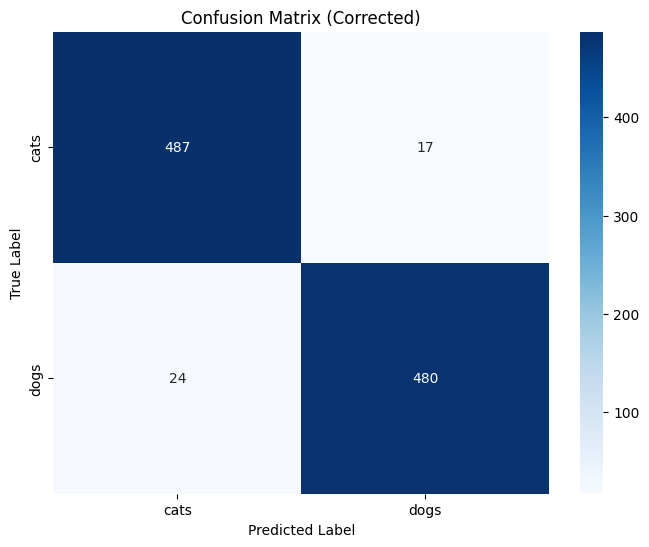

In [ ]:
# Dự đoán trên tập validation
y_pred_prob = best_model.predict(validation_generator, steps=len(validation_generator), verbose=1) # Đổi tên để rõ ràng hơn

# Nhãn thật (true labels)
y_true = validation_generator.classes

# Kiểm tra class indices để biết 0 là gì, 1 là gì
print("Class Indices:", validation_generator.class_indices)
# Ví dụ: {'cats': 0, 'dogs': 1}

# Chuyển đổi xác suất thành lớp dự đoán (0 hoặc 1) bằng ngưỡng 0.5
threshold = 0.5
y_pred_classes = (y_pred_prob > threshold).astype(int)

# Có thể cần flatten y_pred_classes nếu nó đang là (số_lượng_mẫu, 1)
y_pred_classes = y_pred_classes.flatten()

# --- Tính và vẽ lại Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred_classes)

# Lấy tên lớp theo đúng thứ tự của chỉ số (0, 1, ...)
class_labels = list(validation_generator.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, # Sử dụng tên lớp đã lấy
            yticklabels=class_labels) # Sử dụng tên lớp đã lấy
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Corrected)')
plt.show()

In [ ]:
val_loss, val_accuracy = best_model.evaluate(
    validation_generator,
    steps=len(validation_generator),
    verbose=1
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9706 - loss: 0.1149
Validation Loss: 0.1470
Validation Accuracy: 0.9593


In [ ]:
from sklearn.metrics import classification_report

# 1. Dự đoán xác suất
y_pred_prob = best_model.predict(validation_generator, steps=len(validation_generator), verbose=1)

# 2. Chuyển về nhãn 0 hoặc 1 với threshold 0.5
y_pred_classes = (y_pred_prob > 0.5).astype(int).flatten()

# 3. Lấy nhãn thực
y_true = validation_generator.classes

# 4. Lấy tên class theo đúng index
class_labels = list(validation_generator.class_indices.keys())

# 5. In classification report (Precision, Recall, F1 cho từng nhãn)
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step
Classification Report:
              precision    recall  f1-score   support

        cats       0.95      0.97      0.96       504
        dogs       0.97      0.95      0.96       504

    accuracy                           0.96      1008
   macro avg       0.96      0.96      0.96      1008
weighted avg       0.96      0.96      0.96      1008



### Make prediction

In [ ]:
test_frames = [validation_cats_dir + "/" + frame for frame in validation_cat_frame[:10]] + [validation_dogs_dir + "/" + frame for frame in validation_dog_frame[:10]]

In [ ]:
def make_prediction(test_frames):
  for frame_path in test_frames:
    print("-" * 30)
    print(f"Processing: {frame_path}")

    try:
        # 1. Tải ảnh gốc để hiển thị (không cần chuyển thành array ngay)
        img_for_display = tf.keras.preprocessing.image.load_img(frame_path, target_size=(224, 224))

        # 2. Chuyển ảnh thành array để chuẩn bị cho mô hình
        img_array = tf.keras.preprocessing.image.img_to_array(img_for_display)

        # 3. Thêm chiều batch
        img_batch = np.expand_dims(img_array, axis=0)

        # 4. Chuẩn hóa pixel (!!! QUAN TRỌNG: Phải giống hệt generator !!!)
        img_processed = img_batch / 255.0

        # 5. Dự đoán
        prediction = best_model.predict(img_processed)
        prediction_prob_dog = prediction[0][0]  # Lấy xác suất là chó

        # 6. Xác định nhãn dự đoán
        threshold = 0.5
        if prediction_prob_dog > threshold:
            predicted_label = 'Dog'
            predicted_prob = prediction_prob_dog  # Xác suất của chó
        else:
            predicted_label = 'Cat'
            predicted_prob = 1 - prediction_prob_dog  # Xác suất của mèo (1 - xác suất của chó)

        print(f"Predicted Probability (Dog): {prediction_prob_dog:.4f}")
        print(f"Predicted Label: {predicted_label}")

        # 7. Hiển thị ảnh và nhãn dự đoán
        plt.figure()  # Tạo một figure mới cho mỗi ảnh
        plt.imshow(img_for_display)  # Hiển thị ảnh gốc đã tải (chưa rescale)

        # Tùy chỉnh title dựa vào nhãn
        if predicted_label == 'Dog':
            plt.title(f"Predicted: Dog\n(Accuracy: {predicted_prob * 100:.2f}%)", color='green')
        else:
            plt.title(f"Predicted: Cat\n(Accuracy: {predicted_prob * 100:.2f}%)", color='blue')

        plt.axis('off')
        plt.show()

    except FileNotFoundError:
        print(f"Error: File not found at {frame_path}")
    except Exception as e:
        print(f"An error occurred processing {frame_path}: {e}")


------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/cats/cat.1018.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Predicted Probability (Dog): 0.0747
Predicted Label: Cat


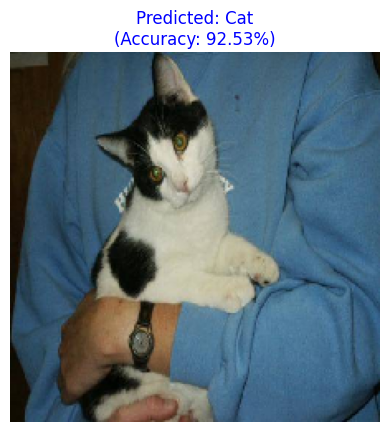

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/cats/cat.1127.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted Probability (Dog): 0.0433
Predicted Label: Cat


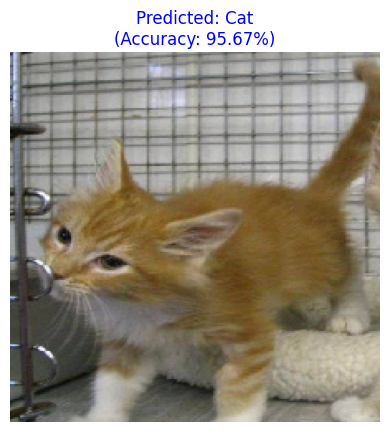

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/cats/cat.1063.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Probability (Dog): 0.0086
Predicted Label: Cat


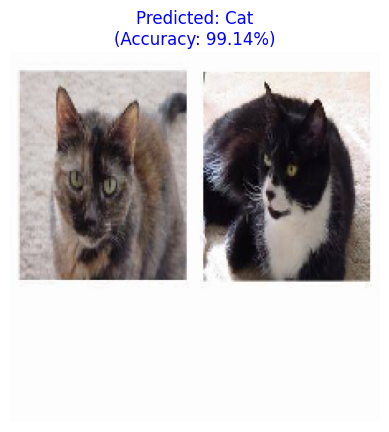

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/cats/cat.1172.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted Probability (Dog): 0.0207
Predicted Label: Cat


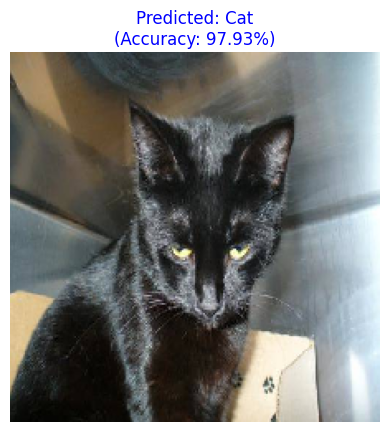

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/cats/cat.1130.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Probability (Dog): 0.0184
Predicted Label: Cat


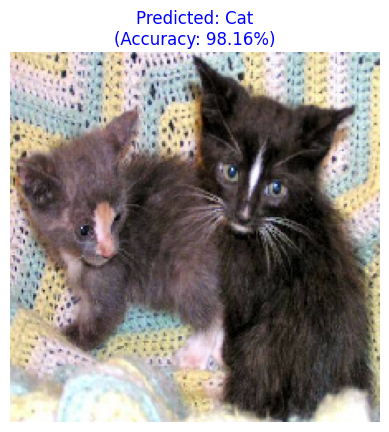

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/cats/cat.1146.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Probability (Dog): 0.0168
Predicted Label: Cat


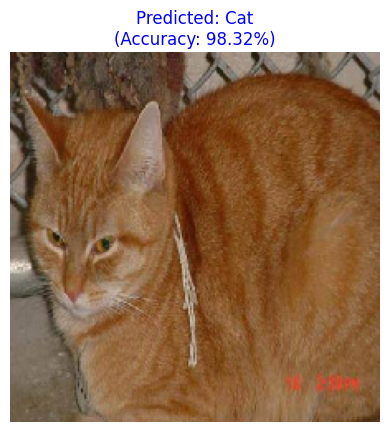

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/cats/cat.1082.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicted Probability (Dog): 0.0546
Predicted Label: Cat


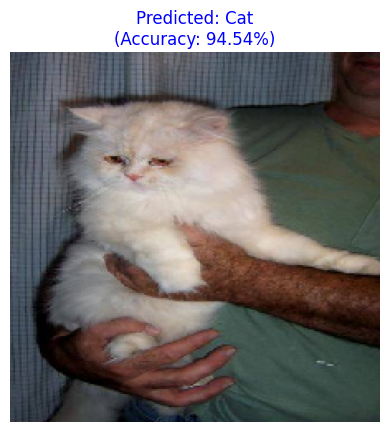

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/cats/cat.1037.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted Probability (Dog): 0.0110
Predicted Label: Cat


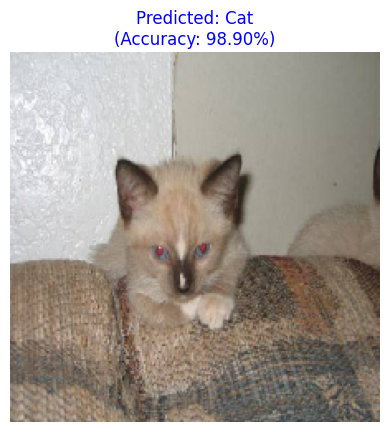

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/cats/cat.1221.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Predicted Probability (Dog): 0.1066
Predicted Label: Cat


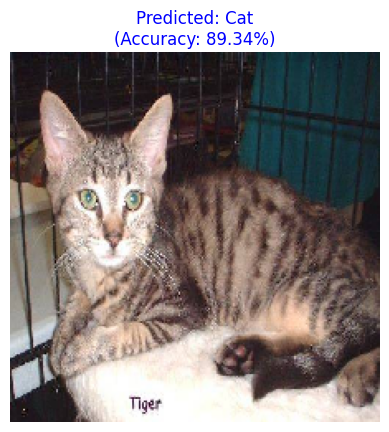

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/cats/cat.1002.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted Probability (Dog): 0.0160
Predicted Label: Cat


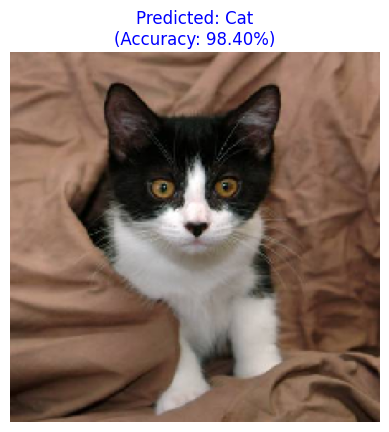

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/dogs/dog.1065.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted Probability (Dog): 0.9686
Predicted Label: Dog


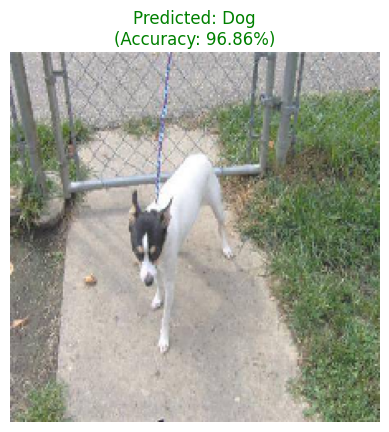

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/dogs/dog.1053.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Predicted Probability (Dog): 0.9853
Predicted Label: Dog


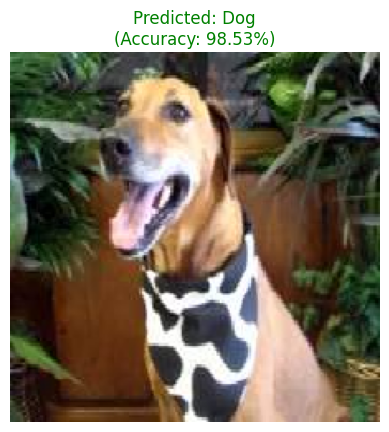

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/dogs/dog.1139.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted Probability (Dog): 0.9324
Predicted Label: Dog


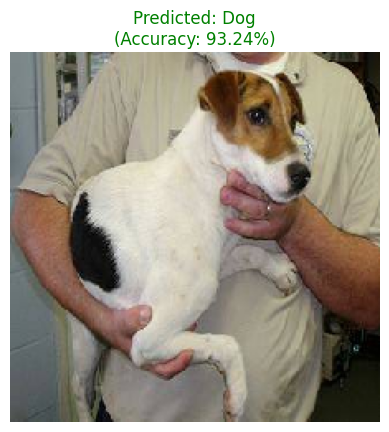

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/dogs/dog.1115.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Predicted Probability (Dog): 0.6980
Predicted Label: Dog


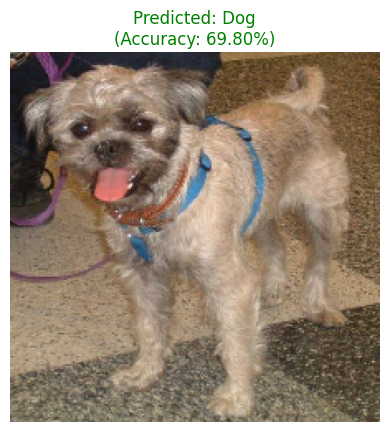

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/dogs/dog.1130.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted Probability (Dog): 0.8305
Predicted Label: Dog


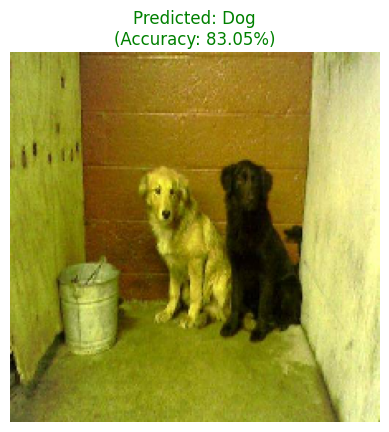

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/dogs/dog.1028.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted Probability (Dog): 0.9292
Predicted Label: Dog


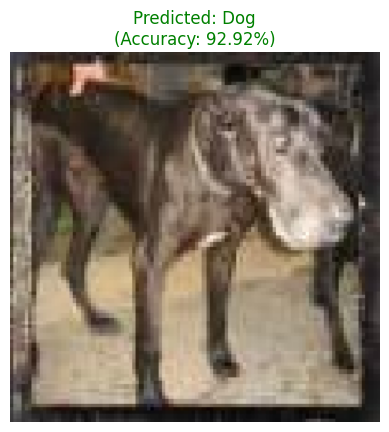

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/dogs/dog.1090.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted Probability (Dog): 0.7716
Predicted Label: Dog


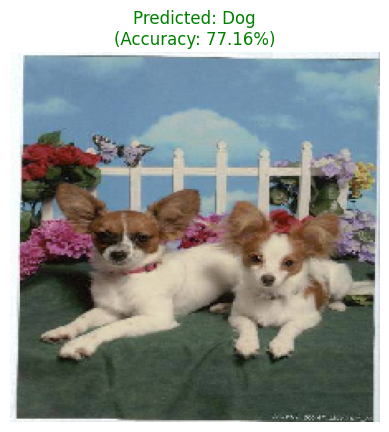

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/dogs/dog.1157.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Predicted Probability (Dog): 0.9553
Predicted Label: Dog


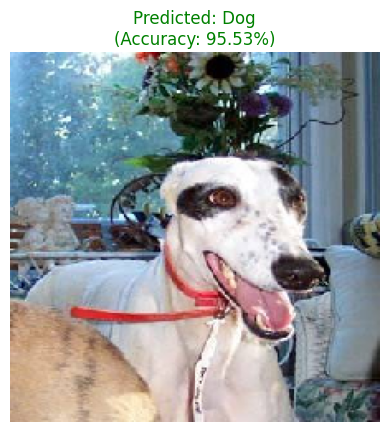

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/dogs/dog.1175.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Predicted Probability (Dog): 0.8195
Predicted Label: Dog


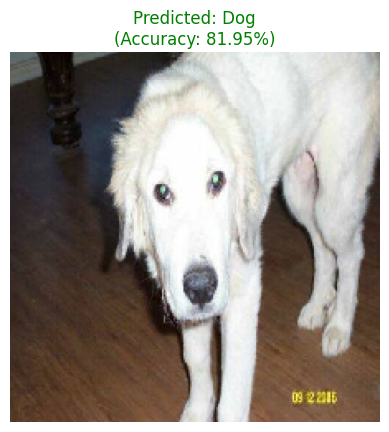

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/dogs/dog.1052.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted Probability (Dog): 0.9584
Predicted Label: Dog


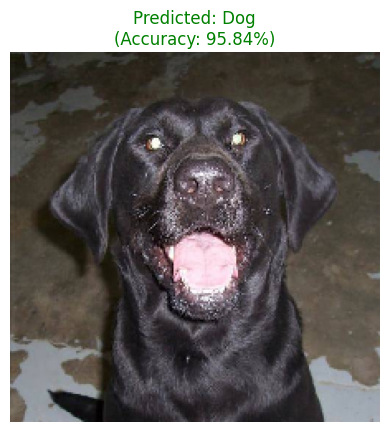

In [ ]:
make_prediction(test_frames)

### Test with VGG16 mispredicted images

In [ ]:
test_frames = [validation_cats_dir + "/" + "cat.1003.jpg", validation_cats_dir + "/" + "cat.1004.jpg"]

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/cats/cat.1003.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted Probability (Dog): 0.0262
Predicted Label: Cat


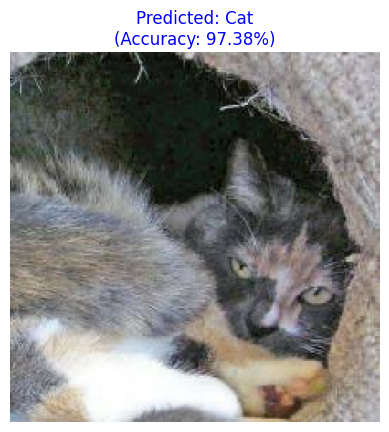

------------------------------
Processing: /content/drive/MyDrive/Colab/Advanced_AI/data/validation/cats/cat.1004.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Predicted Probability (Dog): 0.0573
Predicted Label: Cat


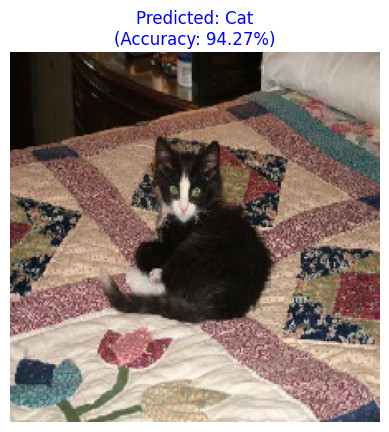

In [ ]:
make_prediction(test_frames)